<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct_logo.png" alt="UPCT" style="height:145px; width:auto;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu_logo.png" alt="UMU" style="height:200px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 4: Autocodificadores
### **Sesión 1/3: Autocodificadores para detección de anomalías**

**Autores**: Juan Morales Sánchez, Antonio Martínez Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya
___

### Objetivos

- Definición de la arquitectura básica de un *autoencoder* (encoder y decoder).
- Diseño de un *autoencoder* totalmente conectado.
- Comprender la reducción de dimensionalidad asociada al espacio latente.
- Representar la reconstrucción de señal realizada por un *autoencoder*.
- Aplicación a la detección de anomalías en series temporales.

### Contenidos
- [El dataset ECG5000](#dataset)
- [Concepto de *autoencoder*](#concepto)
- [*Autoencoder* totalmente conectado](#autoencoder)
- [Ejercicios](#ejercicios)

### Requisitos 
<a class='anchor' id='requisitos'></a>

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (*Machine Learning*)
- [Scikit-image](https://pypi.org/project/scikit-image/) (*Image Processing*)
- [Matplotlib](https://pypi.org/project/matplotlib/) y [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)
- [Tensorflow](https://www.tensorflow.org/) 2.x que incluye a [Keras](https://www.tensorflow.org/guide/keras) 2.x (*Deep Learning*)



<a class='anchor' id='dataset'></a>

## El dataset ECG5000

El [dataset ECG5000](https://www.timeseriesclassification.com/description.php?Dataset=ECG5000) tiene como ejemplos de entrenamiento series temporales. Estas se corresponden con señales de electrocardiogramas (ECG) utilizadas principalmente para la detección de anomalías cardíacas. 

Originalmente, el dataset contiene diferentes tipos de anomalías: anomalía tipo R-on-T, anomalía tipo PVC (extrasístole ventricular), anomalía tipo SP (latido supernormal) y anomalía tipo UB (latido desconocido). Cada ejemplo se corresponde con una de estas anomalías, y así se etiqueta. En esta práctica se utilizará una [versión simplificada del dataset ECG5000](http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv), de clasificación binaria, en el que se han reducido los ejemplos a clase "normal" y clase "anómala", más adecuado para el problema de detección de anomalías que se pretende abordar aquí.

### Características del dataset ECG5000 con etiquetado binario

- **Origen**: Derivado de la base de datos de ECG de BIDMC (Beth Israel Deaconess Medical Center).
- **Cantidad de muestras**: 5000 registros de ECG.
- **Longitud de cada serie temporal**: 140 instantes temporales.
- **Etiquetas**: (la última columna de cada registro es la etiqueta, y las 140 restantes son la señal ECG)
  - Clase 1: "normal" (se considerará conocida durante el aprendizaje)
  - Clase 0: "anómala" (se considerará desconocida durante el aprendizaje)

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="images/dataset_ECG5000.png" style="height:500px; width:auto;">
</div>

<a class='anchor' id='concepto'></a>

## *Autoencoders*

Los *autoencoders* son redes neuronales diseñadas para aprender representaciones (codificaciones) compactas y eficientes de los datos de entrada, de forma no supervisada. Su estructura básica se compone de dos partes:

- **Codificador (*Encoder*):** Transforma la entrada en una representación interna (codificación) de menor dimensión, dentro del denominado espacio latente (z).
- **Decodificador (*Decoder*):** Reconstruye la entrada original a partir de esa representación en dicho espacio latente.

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="images/AE_pyramid.png" style="height:300px; width:auto">
</div>

### Variantes de *autoencoders*

1. ***Autoencoder* totalmente conectado:**  
   Emplea capas totalmente conectadas y aprende a reconstruir la entrada minimizando el error de reconstrucción. La representación intermedia es determinista y se utiliza principalmente para reducción de dimensionalidad (compresión, detección de anomalías, etc.), pero capturando relaciones no lineales, a diferencia de otras técnicas como PCA. Se probará precisamente en este primer notebook de esta última práctica, la práctica número 4.

2. ***Sparse autoencoder*:**  
   Incorpora restricciones de dispersión en la representación latente para fomentar que solo un subconjunto de neuronas se active, lo que mejora la interpretabilidad y captura de características importantes. Se probará durante la siguiente sesión de esta práctica.

3. ***Denoising autoencoder*:**  
   Se entrena para reconstruir la entrada original a partir de versiones corrompidas o ruidosas de la misma, lo que lo hace útil para aprender representaciones robustas y para tareas de eliminación de ruido. No se probará en esta práctica, ya que la idea es similar a la ensayada durante la sesión 2 de la práctica 2 con la U-Net.

4. ***Autoencoder* convolucional (*Convolutional AutoEncoder* o CAE):**  
   Se aplica típicamente a imágenes, y es similar a un *autoencoder* totalmente conectado, pero utiliza capas convolucionales que sustituyen a las capas densas tradicionales, lo que habitualmente permite aprender patrones locales y estructuras espaciales de manera más eficiente. Se probará durante la sesión 2 de esta práctica 4.

5. ***Autoencoder* variacional (*Variational AutoEncoder* o VAE):**  
   Introduce un enfoque probabilístico, modelando la representación latente como una distribución de probabilidad (generalmente gaussiana). Además del error de reconstrucción, se añade un término de divergencia Kullback-Leibler para regularizar la distribución del espacio latente. Esto permite generar nuevos datos tomando muestras aleatorias de dicho espacio latente. Se probará durante la sesión 3 de esta práctica 4.


<a class='anchor' id='autoencoder'></a>

## *Autoencoder* totalmente conectado

Para diseñar un autoencoder totalmente conectado en ```tensorflow``` lo habitual es construir 3 modelos diferentes, pero enlazados: codificador, decodificador y autocodificador. Utilizando la definición funcional de modelos de ```tensorflow``` la implementación podría seguir esta estructura:

**Codificador**
```python
input = keras.layers.Input(shape=INPUT_SHAPE)                   # Nivel 0 (espacio base)
x = keras.layers.Dense(DIM_1, activation=ACTIVATION)(input)     # Nivel 1
x = keras.layers.Dense(DIM_2, activation=ACTIVATION)(x)         # Nivel 2
x = keras.layers.Dense(DIM_3, activation=ACTIVATION)(x)         # Nivel 3
.                                                               .
.                                                               .
encoded_z = keras.layers.Dense(LATENT_DIM)(x)                   # Nivel N (espacio latente)
encoder = keras.Model(input, encoded_z)                         # Modelo codificador: datos de entrada -> codificación en espacio latente
```

**Decodificador**
```python
.                                                               .
.                                                               .
x = keras.layers.Dense(DIM_3, activation=ACTIVATION)(encoded_z) # Nivel 3
x = keras.layers.Dense(DIM_2, activation=ACTIVATION)(x)         # Nivel 2
x = keras.layers.Dense(DIM_1, activation=ACTIVATION)(x)         # Nivel 1
reconstructed = keras.layers.Dense(INPUT_SHAPE[0])(x)           # Nivel 0 (espacio base)
decoder = keras.Model(encoded_z, reconstructed)                 # Modelo decodificador: codificación en espacio latente -> datos reconstruidos
```

**Autocodificador**
```python
autoencoder = keras.Model(input, reconstructed)                 # Modelo autocodificador: datos de entrada -> datos reconstruidos
```

El objetivo de esta sesión de prácticas es implementar un modelo de apredizaje automático basado en un *autoencoder* para la detección de anomalías en ECGs. Para ello se entrenará un *autoencoder* solo con ECGs normales, y luego se evaluará su capacidad de detección de latidos anómalos en un conjunto mixto (normales y anómalos) de ECGs, haciendo uso para ello de un umbral en el error de reconstrucción. A continuación se muestra un ejemplo de codificación-decodificación.

<div style="display:flex; justify-content:space-around; align-items:center; padding:5px solid #333333;">
    <img src="images/AE_ECGs.png" style="height:800px; width:auto;">
</div>

- Usaremos el [coeficiente de determinación $R^2$](https://es.wikipedia.org/wiki/Coeficiente_de_determinaci%C3%B3n) para estimar la fidelidad de la señal reconstruida: similitud de la señal recuperada con la original, a nivel de coeficiene $R^2$.

```python
    r2 = np.zeros(len(x_test))
    for i in range(len(x_test)):
        r2[i] = r2_score(x_test[i].flatten(), decoded[i].flatten())
    r2 = r2.mean()
    print(f"Calidad de reconstrucción (coeficiente R2 medio): {r2*100:.2f} %")
```

- Estimaremos también la hipotética compresión o reducción de la dimensionalidad que conlleva la codificación alcanzada en el espacio latente: cociente entre el número de características de la muestra original y la dimensión de su codificación en el espacio latente.

```python
    print(f"Compresión de la codificación: {LATENT_DIM/np.prod(INPUT_SHAPE)*100:.2f} %")
```

- Por último, prestaremos atención a los posibles valores nulos de la codificación alcanzada en el espacio latente (es este ejemplo no los habrá), lo que en su caso indicaría una codificación dispersa (*sparse*).

```python
    print(f"Coeficientes no nulos: {np.count_nonzero(np.sum(encoded, axis=0)):d}/{LATENT_DIM}")
```

# Ejercicios

**E1:** Descargue el [dataset ECG5000 simplificado](http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv), lea el CSV y genere las variables de trabajo: registros ECGs normales y anómalos por separado, así como las correspondientes etiquetas de cada uno de ellos (reetiquete clase 0 -> normal, clase 1 -> anómalo). Particione el conjunto de entrenamiento (70% de los ECGs normales) y el conjunto de test (30% restante de los ECGs normales, más todos del ECGs anómalos).

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

datos = pd.read_csv('./ecg.csv')

datos['1.0'] = datos['1.0'].map({0.0:'normal', 1.0: 'anómalo'})

# Filtrar las filas que son 'normal' y 'anómalo'
normal = datos[datos['1.0'] == 'normal']
anomalo = datos[datos['1.0'] == 'anómalo']

# Dividir el 70% y 30% de las filas 'normal'
normal_train, normal_test = train_test_split(normal, test_size=0.3, random_state=42)

# Combinar el 30% de 'normal' con todas las filas 'anómalo' para el conjunto de prueba
test = pd.concat([normal_test, anomalo])

# El conjunto de entrenamiento contiene el 70% de 'normal'
train = normal_train

# Dividir las características (primeras 140 columnas) y las etiquetas (última columna)
x_train = train.iloc[:, :140]  # Primeras 140 columnas como características
y_train = train.iloc[:, -1]    # Última columna como etiquetas

x_test = test.iloc[:, :140]    # Primeras 140 columnas como características
y_test = test.iloc[:, -1]      # Última columna como etiquetas


INPUT_SHAPE = x_train.shape

# Mostrar los tamaños de los conjuntos
print(f"Conjunto de entrenamiento: {train.shape}")
print(f"Conjunto de prueba: {test.shape}")

Conjunto de entrenamiento: (1455, 141)
Conjunto de prueba: (3542, 141)


**E2:** Siguiendo la guía indicada en el aparado que introduce los [*autoencoders* totalmente conectados](#autoencoder):
- Diseñe la pirámide de codificación-decodificación totalmente conectada, de 3 niveles de profundidad (2 niveles de profundidad adicionales al espacio latente). Utilice para ello secuencias de capas densas decrecientes-crecientes en potencias de 2, y con activación ReLU (salvo en el espacio latente).
- Entrene el modelo empleando optimizador Adam y el error absoluto medio o MAE (Mean Absolute Error) como función de pérdida. Es imprescindible implementar la parada anticipada para evitar el sobreajuste.
- De forma similar a la figura del apartado de [*autoencoders* totalmente conectados](#autoencoder), represente ejemplos de ECGs del conjunto de entrenamiento, con sus correspondientes codificaciones y reconstrucciones para diferentes dimensiones (potencia de 2) del espacio latente.

In [9]:
import keras
# Codificador

input = keras.layers.Input(shape=(INPUT_SHAPE[1],))                   # Nivel 0 (espacio base)
x = keras.layers.Dense(128, activation='relu')(input)     # Nivel 1 (capa oculta)
x = keras.layers.Dense(64, activation='relu')(x)         # Nivel 2	(capa oculta)
encoded_z = keras.layers.Dense(32)(x)                   # Nivel 3 (espacio latente)
encoder = keras.Model(input, encoded_z)                 # Modelo codificador: datos de entrada -> codificación en espacio latente


# Decodificador                                                
x = keras.layers.Dense(64, activation='relu')(encoded_z) 		# Nivel 2 (capa oculta)
x = keras.layers.Dense(128, activation='relu')(x)         # Nivel 1 (capa oculta)
reconstructed = keras.layers.Dense(INPUT_SHAPE[1], activation = 'linear')(x)           # Nivel 0 (espacio base)
decoder = keras.Model(encoded_z, reconstructed)                 # Modelo decodificador: codificación en espacio latente -> datos reconstruidos

# Autocodificador
autoencoder = keras.Model(input, reconstructed)         

In [10]:
# Entrenamos el modelo

from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',   # si tu modelo compila con metrics=['mae']
    patience=5,
    restore_best_weights=True,
    mode='min',
    verbose=1
)


autoencoder.compile(optimizer='adam', loss='MAE', metrics=['mae'])

history = autoencoder.fit(x_train, x_train,
    validation_split=0.1,
    batch_size=32,
    epochs = 200,
	callbacks = [early_stopping])


Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4528 - mae: 0.4528 - val_loss: 0.2804 - val_mae: 0.2804
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2426 - mae: 0.2426 - val_loss: 0.2176 - val_mae: 0.2176
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2059 - mae: 0.2059 - val_loss: 0.1896 - val_mae: 0.1896
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1748 - mae: 0.1748 - val_loss: 0.1583 - val_mae: 0.1583
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1447 - mae: 0.1447 - val_loss: 0.1322 - val_mae: 0.1322
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1257 - mae: 0.1257 - val_loss: 0.1206 - val_mae: 0.1206
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1150 - mae: 0.1150 - val_loss: 0.1118 - val_mae: 0.1118
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1094 - mae: 0.1094 - val_loss: 0.1089 - val_mae: 0.1089
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.103

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


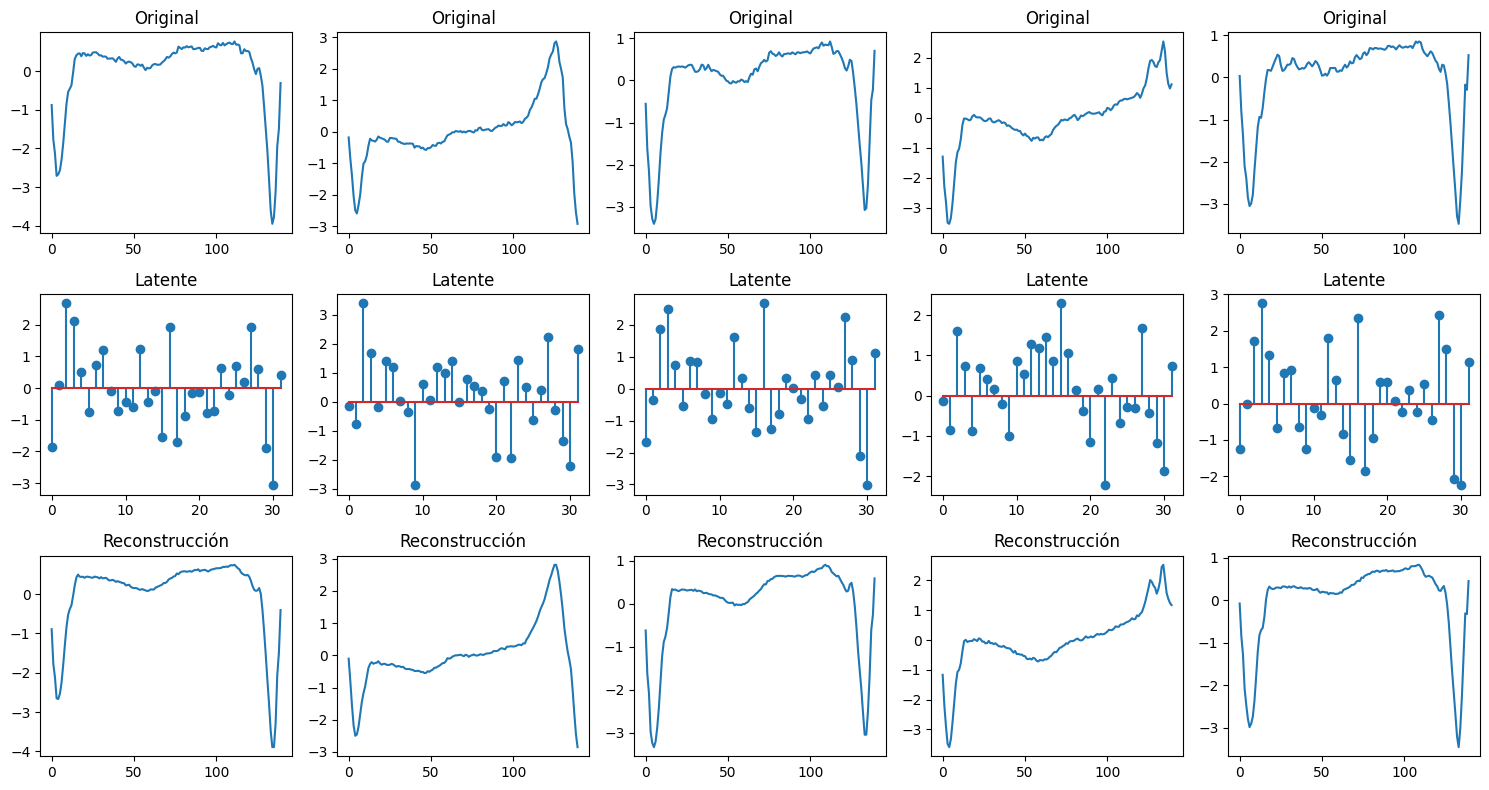

In [11]:
import matplotlib.pyplot as plt

# Mostramos algunos ejemplos codificados y reconstruidos
ejemplos = x_train[:5]

# Obtenemos codificaciones
codificaciones = encoder.predict(ejemplos)

# Obtenemos reconstrucciones
reconstrucciones = decoder.predict(codificaciones)

# Creamos la figura
fig, axes = plt.subplots(3, 5, figsize=(15, 8))

# Primera fila: Ejemplos originales
for i in range(5):
    axes[0, i].plot(ejemplos.iloc[i].values)  
    axes[0, i].set_title("Original")


# Segunda fila: Codificaciones en el espacio latente
for i in range(5):
    axes[1, i].stem(codificaciones[i])  
    axes[1, i].set_title("Latente")


# Tercera fila: Reconstrucciones
for i in range(5):
    axes[2, i].plot(reconstrucciones[i])
    axes[2, i].set_title("Reconstrucción")


plt.tight_layout()
plt.show()

**E3:** Evalúe  el modelo entrenado sobre el conjunto de test. Con el objetivo de comparar las diferencias en cuanto a la fidelidad de la reconstrucción de los ECGs normales y los anómalos:
- Represente al menos un ECG de cada tipo (ECG normal y anómalo), superpuesto en la misma gráfica con su correspondiente reconstrucción.
- Constate esta diferencia calculando los valores numéricos de MAE que se alcanzan para cada tipo de ECG.
- Represente el histograma de los errores MAE de reconstrucción del conjunto de test, y compárelo con el histograma del entrenamiento (se recomienda representar ambos histogramas en la misma gráfica).

Umbral de anomalía (percentil 95): 0.105962455


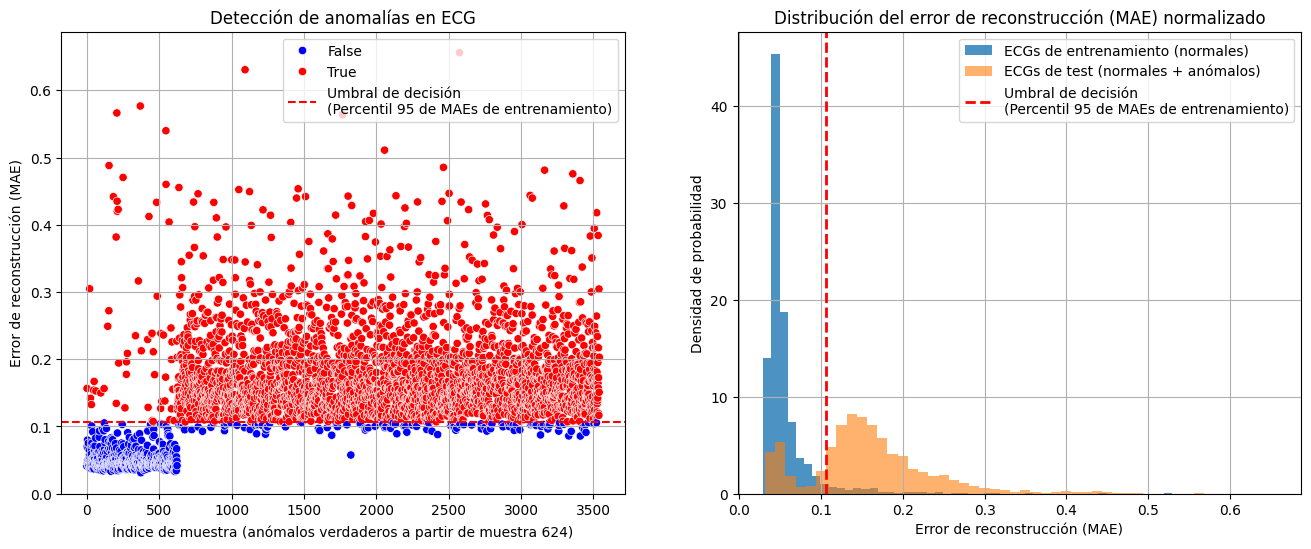

In [12]:
from tensorflow.keras import losses
import numpy as np
import seaborn as sns

# Primero evaluamos para el train
# Evaluar la detección de anomalías
x_train_pred = autoencoder.predict(x_train, verbose=0)
train_mae = losses.mae(x_train, x_train_pred).numpy()


# Calcular el error de reconstrucción para cada muestra del conjunto de prueba
x_test_pred = autoencoder.predict(x_test, verbose=0)
test_mae = losses.mae(x_test, x_test_pred).numpy()

# Clasificar las muestras: si el error supera el umbral el ECG se considera anómalo
threshold = np.percentile(train_mae, 95)
print("Umbral de anomalía (percentil 95):", threshold)

anomalies = test_mae > threshold

# Visualizar los resultados de detección sobre todas las muestras del conjunto de test
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=range(len(test_mae)), y=test_mae, hue=anomalies, palette=['blue', 'red'], ax=axes[0])
axes[0].axhline(y=threshold, color='r', linestyle='--', label='Umbral de decisión\n(Percentil 95 de MAEs de entrenamiento)')
axes[0].grid()
axes[0].set_xlabel(f"Índice de muestra (anómalos verdaderos a partir de muestra {len(x_test)-len(anomalo):d})")
axes[0].set_ylabel("Error de reconstrucción (MAE)")
axes[0].set_title("Detección de anomalías en ECG")
axes[0].legend()

# Visualizar la distribución del error de reconstrucción
axes[1].hist(train_mae, bins=50, density=True, alpha=0.8, label="ECGs de entrenamiento (normales)")
axes[1].hist(test_mae, bins=50, density=True, alpha=0.6, label="ECGs de test (normales + anómalos)")
axes[1].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label='Umbral de decisión\n(Percentil 95 de MAEs de entrenamiento)')
axes[1].grid()
axes[1].set_xlabel("Error de reconstrucción (MAE)")
axes[1].set_ylabel("Densidad de probabilidad")
axes[1].set_title("Distribución del error de reconstrucción (MAE) normalizado")
axes[1].legend(loc='upper right')
plt.show()

**E4:** En base a los resultados anteriores, razone si se observa presumible separabilidad por umbral entre los ECGs normales y anómalas del conjunto de test, y estime un posible valor umbral (un cierto percentil de los errores MAE de reconstrucción del conjunto de test) que permita la separación (detección) de los ECGs anómalos. Según este criterio, un registro del conjunto de test se considerará anómalo si su MAE de reconstrucción supera dicho umbral. Aplique el umbral de detección, y clasifique los registros ECG del conjunto de test en "normales" o "anómalos"


Al representar el MAE de tests, se observan dos regiones de error, a la izquierda que son los normales y la derecha que son los anómalos. Tenemos una distribución bimodal que tiene separabilidad, por lo tanto podemos detectar aquellos casos que son anómalos.

**E5:** Si se desean unas prestaciones de sensibilidad mínima de detección de ECGs anómalos del 99%, calcule la [especificidad esperable](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/SpecificityAtSensitivity) (el valor objetivo estaría cercano o superando el 95%). Experimente con el aumento o disminución en potencias de 2 del número de neuronas de la pirámide del *autoencoder* o el umbral de detección. Experimente también el beneficio que aporta la [estandarización inicial](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) de los registros ECG.

In [13]:
from sklearn.metrics import recall_score

# Convertimos y_test a boolenaos para evitar errores de compatibilidad

y_test_bool = (y_test == 'anómalo').astype(int)

# Cálculo de sensibilidad y especificidad de detección de anomalías
sensitivity = recall_score(y_test_bool, anomalies)
specificity = recall_score(np.logical_not(y_test_bool), np.logical_not(anomalies))
print(f"Sensibilidad de detección de ECGs anómalos: {sensitivity*100:.2f}%")
print(f"Especificidad de detección de ECGs anómalos: {specificity*100:.2f}%")
sensitivity = 0.99
specificity = keras.metrics.SpecificityAtSensitivity(sensitivity)
specificity.update_state(y_test_bool, test_mae)
print(f"Especificidad de detección de ECGs anómalos para una sensibilidad del {sensitivity*100:.2f}%: {specificity.result().numpy()*100:.2f}%")

Sensibilidad de detección de ECGs anómalos: 96.30%
Especificidad de detección de ECGs anómalos: 90.87%
Especificidad de detección de ECGs anómalos para una sensibilidad del 99.00%: 89.10%
